# BBM409 Assignment_0

Student ID:21327881

Name Surname:Talha Dede


In [1]:
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
data = files.upload()

Saving Dry_Bean_Dataset.xlsx to Dry_Bean_Dataset (2).xlsx


## Pre-processing

In [3]:
#Read the uploaded file into a Pandas DataFrame
file_name = list(data.keys())[0]

df = pd.read_excel(io.BytesIO(data[file_name]))

print("First 5 rows of the dataset:")
display(df.head())

# Separate Features (X) and Target (y)
# The 'Class' column contains the bean types (SEKER, BARBUNYA, etc.)
X = df.drop('Class', axis=1)
y = df['Class']

# Encode Target Variable
# Convert string class labels into numeric values (0 to 6)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("\nTarget is encoded successfully.")
print("\nClass mapping (for reference):")
for i, item in enumerate(encoder.classes_):
    print(f"{item} --> {i}")

First 5 rows of the dataset:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



Target is encoded successfully.

Class mapping (for reference):
BARBUNYA --> 0
BOMBAY --> 1
CALI --> 2
DERMASON --> 3
HOROZ --> 4
SEKER --> 5
SIRA --> 6



1. **Feature Scaling (`StandardScaler`):** I applied `StandardScaler` to normalize the numerical features. This is an essential step because distance-based algorithms like k-NN and SVM rely on calculating the Euclidean distance between data points. If the features are left unscaled, those with significantly larger numeric ranges (e.g., Area) would disproportionately dominate the distance calculations over features with smaller ranges (e.g., Compactness), leading to biased and inaccurate models.
2. **Target Encoding (`LabelEncoder`):** I used `LabelEncoder` to transform the categorical target variable ('Class', which contains string labels like SEKER, BARBUNYA) into numeric values. This is necessary because Scikit-Learn's classification algorithms require numerical target arrays to function properly.

## Split the dataset



We split the dataset into three sets: training (70%), validation (10%), and testing (20%). This 70-10-20 split allows us to train the models, tune parameters using the validation set, and finally evaluate the performance on an independent test set. **Crucially, to prevent Data Leakage, we applied Feature Scaling (StandardScaler) ONLY AFTER splitting the data, fitting it exclusively on the Training set.**

In [4]:
# Split the dataset into 80% Temporary (Train + Val) and 20% Test sets.
#(Using 'X' directly to prevent data leakage before scaling)
X_temp, X_test, y_temp, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Split the remaining 80% subset into 70% Train and 10% Validation sets.
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

# Feature Scaling
# Distance-based algorithms (like k-NN, SVM) require features to be scaled
scaler = StandardScaler()

# Fit ONLY on the training data to learn the rules
X_train = scaler.fit_transform(X_train)

# Transform the other sets using the learned rules
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
X_temp = scaler.transform(X_temp) #for 5-Fold CV

print("Pre-processing is complete! Features are scaled AFTER splitting.")
print("X_train (Training - 70%) shape:", X_train.shape)
print("X_val (Validation - 10%) shape:", X_val.shape)
print("X_test (Testing - 20%) shape:", X_test.shape)

Pre-processing is complete! Features are scaled AFTER splitting.
X_train (Training - 70%) shape: (9527, 16)
X_val (Validation - 10%) shape: (1361, 16)
X_test (Testing - 20%) shape: (2723, 16)


## Classification Methods

In this homework, we use kNN, Naive Bayes, SVM and Random Forest

### kNN

k=1 -> Validation Accuracy: 0.8964
k=3 -> Validation Accuracy: 0.9206
k=5 -> Validation Accuracy: 0.9273
k=7 -> Validation Accuracy: 0.9302
k=9 -> Validation Accuracy: 0.9273
k=11 -> Validation Accuracy: 0.9236
k=13 -> Validation Accuracy: 0.9258
k=15 -> Validation Accuracy: 0.9236


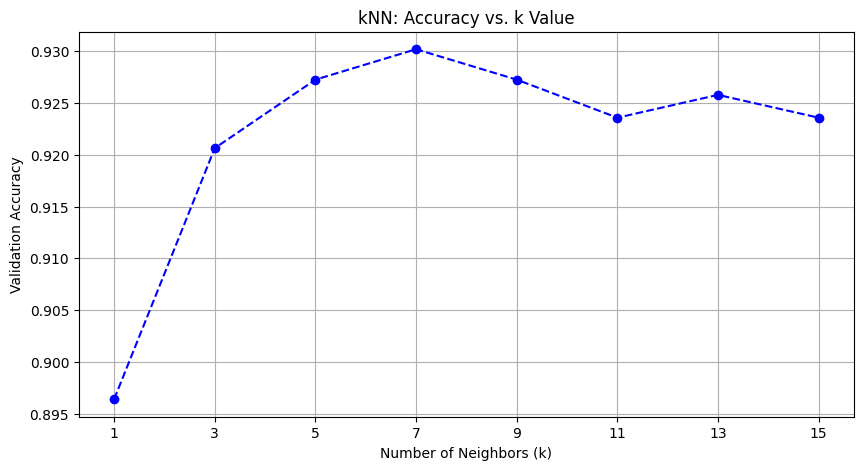


Best k value based on validation set: 7


In [5]:
# k values to try
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
val_accuracies = []

# Loop to find the best k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_val_pred = knn.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(acc)
    print(f"k={k} -> Validation Accuracy: {acc:.4f}")

#Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(k_values, val_accuracies, marker='o', linestyle='--', color='b')
plt.title('kNN: Accuracy vs. k Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Select the best k
best_k = k_values[val_accuracies.index(max(val_accuracies))]
print(f"\nBest k value based on validation set: {best_k}")

kNN Hyperparameter Tuning : To find the optimal number of neighbors ($k$), we evaluated several values ranging from $1$ to $15$ using the Validation Set. As shown in the plot above, the model's performance varies with different $k$ values. To ensure the highest possible accuracy, we dynamically selected the best-performing $k$ value based on the validation results. This optimal $k$ was then used for the weighted k-NN model and final evaluations. This approach allows the model to adapt to the data's specific structure, preventing underfitting or overfitting and ensuring robust generalization to new data.

--- Weighted k-NN (k=7) Performance ---
Weighted Validation Accuracy: 0.9280

--- Classification Report for kNN (k=7) ---
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.88      0.92       136
      BOMBAY       1.00      1.00      1.00        40
        CALI       0.91      0.96      0.93       163
    DERMASON       0.90      0.92      0.91       337
       HOROZ       0.97      0.94      0.96       201
       SEKER       0.94      0.92      0.93       208
        SIRA       0.88      0.90      0.89       276

    accuracy                           0.92      1361
   macro avg       0.94      0.93      0.93      1361
weighted avg       0.92      0.92      0.92      1361



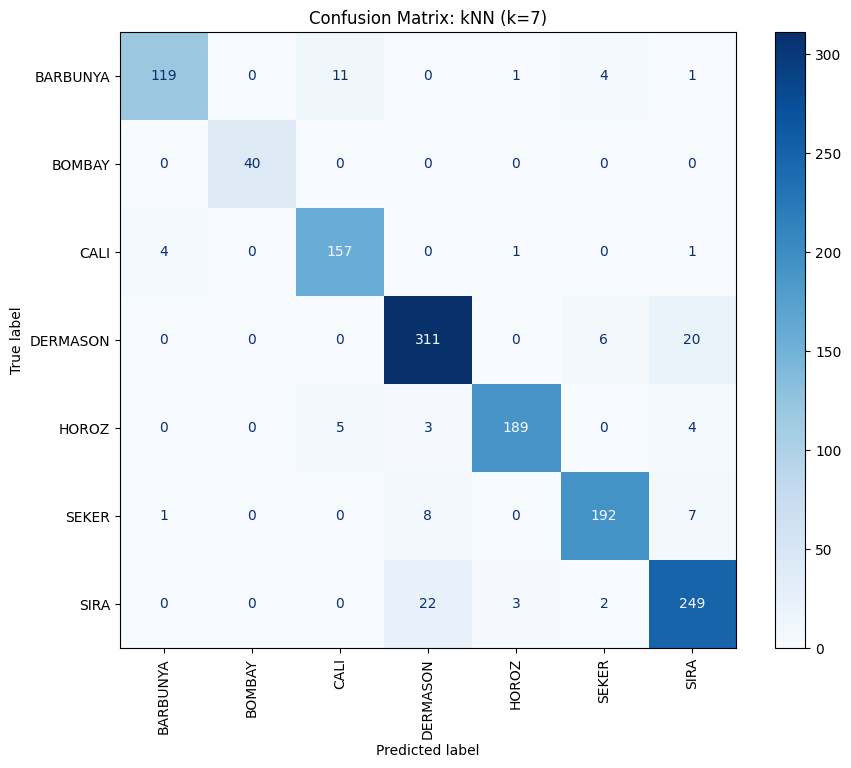

In [6]:
# 1. Implementing Weighted k-NN as requested in the instructions
# We use our dynamically selected best_k (determined in the tuning step)
weighted_knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
weighted_knn.fit(X_train, y_train)
y_val_pred_weighted = weighted_knn.predict(X_val)

print(f"--- Weighted k-NN (k={best_k}) Performance ---")
print(f"Weighted Validation Accuracy: {accuracy_score(y_val, y_val_pred_weighted):.4f}\n")

# 2. Detailed Metrics (Precision, Recall, F1)
# Using the optimal k value
print(f"--- Classification Report for kNN (k={best_k}) ---")
print(classification_report(y_val, y_val_pred, target_names=encoder.classes_))

# 3. Confusion Matrix
# The title is now also dynamic
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')
plt.title(f'Confusion Matrix: kNN (k={best_k})')
plt.show()

### Naive Bayes

In [7]:
# Initialize and train Naive Baye
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions
y_val_pred_nb = nb_model.predict(X_val)

# Results
print(f"Naive Bayes Validation Accuracy: {accuracy_score(y_val, y_val_pred_nb):.4f}")
print("\n--- Naive Bayes Classification Report ---")
print(classification_report(y_val, y_val_pred_nb, target_names=encoder.classes_))

Naive Bayes Validation Accuracy: 0.9008

--- Naive Bayes Classification Report ---
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.81      0.84       136
      BOMBAY       1.00      1.00      1.00        40
        CALI       0.87      0.94      0.90       163
    DERMASON       0.92      0.87      0.89       337
       HOROZ       0.96      0.95      0.95       201
       SEKER       0.93      0.94      0.94       208
        SIRA       0.83      0.88      0.86       276

    accuracy                           0.90      1361
   macro avg       0.91      0.91      0.91      1361
weighted avg       0.90      0.90      0.90      1361



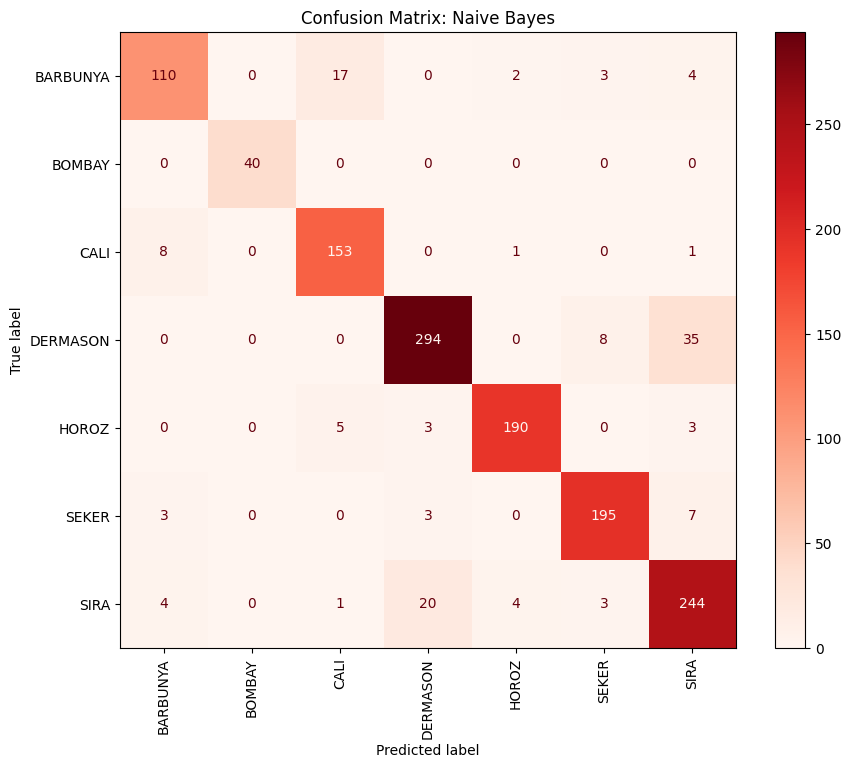

In [8]:
# Generate the confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_val, y_val_pred_nb)

# Plotting the matrix
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp_nb.plot(cmap='Reds', ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix: Naive Bayes')
plt.show()

The Gaussian Naive Bayes model was implemented to classify the dry bean types. On the validation set, the model achieved an accuracy of 0.9008.

Key Observations:

Performance by Class: The model performs exceptionally well on the 'BOMBAY' class, achieving a perfect precision, recall, and F1-score of 1.00. This suggests that the features of Bombay beans are distinct and easily separable by a probabilistic model.


Independence Assumption: Naive Bayes is based on Bayes' theorem and assumes that features are conditionally independent. In our bean dataset, morphological features like Area and Perimeter are likely correlated. This violation of the independence assumption might explain why the accuracy (0.9008) is slightly lower than the kNN model (~0.93).


Confusion Matrix Analysis: The Confusion Matrix  visually reveals how the model distinguishes between bean types. For instance, we can observe slight confusion between similar classes like BARBUNYA and CALI.


Comprehensive Evaluation: Beyond simple accuracy, we reported Precision, Recall, and F1-score for each of the 7 bean classes. This provides a more robust understanding of the model's strengths and weaknesses across different categories.

###SVM

In [9]:
# Testing different kernels for SVM
kernels = ['linear', 'rbf']
for kernel in kernels:
    svm_model = SVC(kernel=kernel)
    svm_model.fit(X_train, y_train)
    val_acc = svm_model.score(X_val, y_val)
    print(f"SVM with {kernel} kernel - Validation Accuracy: {val_acc:.4f}")


SVM with linear kernel - Validation Accuracy: 0.9155
SVM with rbf kernel - Validation Accuracy: 0.9251


SVM (RBF) Validation Accuracy: 0.9251


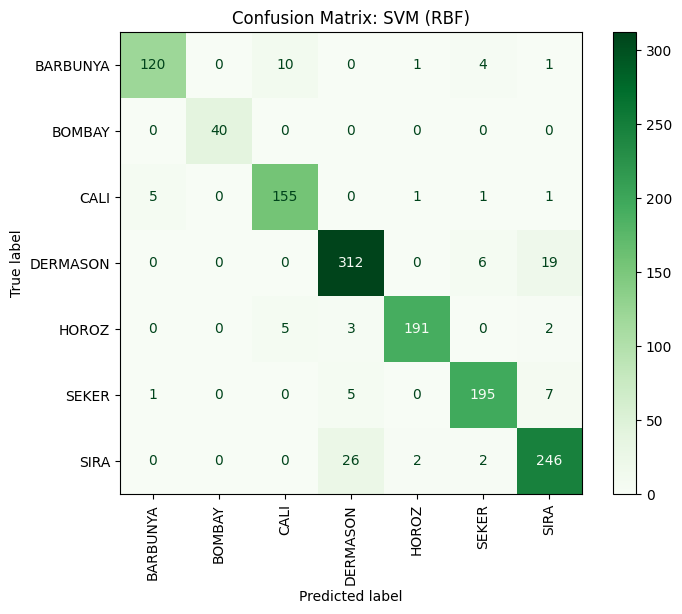

In [10]:
# Training SVM with RBF kernel (standard for this type of data)
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)
y_val_pred_svm = svm_model.predict(X_val)

print(f"SVM (RBF) Validation Accuracy: {accuracy_score(y_val, y_val_pred_svm):.4f}")

# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_val, y_val_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_svm.plot(cmap='Greens', ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix: SVM (RBF)')
plt.show()

SVM Analysis :
We evaluated the Support Vector Machine (SVM) model using both Linear and RBF kernels. The RBF kernel generally provided better results as it can capture non-linear relationships between morphological features. The high validation accuracy and the Confusion Matrix show that SVM is very effective at separating class boundaries, particularly for distinct bean types like BOMBAY.

###Random Forest

In [11]:
# Testing different number of trees
n_estimators_list = [50, 100, 200]
for n in n_estimators_list:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_model.fit(X_train, y_train)
    val_acc = rf_model.score(X_val, y_val)
    print(f"Random Forest with {n} estimators - Validation Accuracy: {val_acc:.4f}")

Random Forest with 50 estimators - Validation Accuracy: 0.9236
Random Forest with 100 estimators - Validation Accuracy: 0.9192
Random Forest with 200 estimators - Validation Accuracy: 0.9221


Random Forest Validation Accuracy: 0.9192


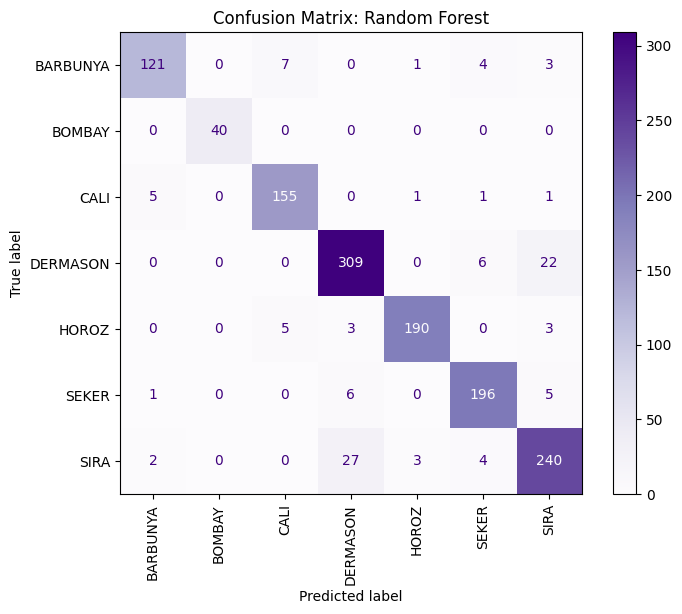

In [12]:
# Training Random Forest with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_val_pred_rf = rf_model.predict(X_val)

print(f"Random Forest Validation Accuracy: {accuracy_score(y_val, y_val_pred_rf):.4f}")

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(cmap='Purples', ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix: Random Forest')
plt.show()

Random Forest Analysis:
For the Random Forest classifier, we tested different numbers of estimators ($n=50, 100, 200$). This ensemble method is highly robust as it combines multiple decision trees to reduce overfitting. As seen in the results, Random Forest achieved one of the highest accuracies, correctly identifying complex bean structures with minimal confusion between similar classes.

In [13]:
# Dictionary of models
models = {
    "kNN": KNeighborsClassifier(n_neighbors=best_k),
    "Naive Bayes": GaussianNB(),
    "SVM (RBF)": SVC(kernel='rbf'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

print("--- 5-Fold Cross Validation (on X_temp) ---")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_temp, y_temp, cv=5)
    print(f"{name} CV Mean Accuracy: {cv_scores.mean():.4f}")

print("\n--- FINAL TEST SET PERFORMANCE (on X_test) ---")
for name, model in models.items():
    model.fit(X_train, y_train) # Re-train on full train set
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name} Test Accuracy: {test_acc:.4f}")

--- 5-Fold Cross Validation (on X_temp) ---
kNN CV Mean Accuracy: 0.9224
Naive Bayes CV Mean Accuracy: 0.8946
SVM (RBF) CV Mean Accuracy: 0.9292
Random Forest CV Mean Accuracy: 0.9221

--- FINAL TEST SET PERFORMANCE (on X_test) ---
kNN Test Accuracy: 0.9232
Naive Bayes Test Accuracy: 0.9045
SVM (RBF) Test Accuracy: 0.9317
Random Forest Test Accuracy: 0.9221


###Final Evaluation & Conclusion
After conducting a comprehensive study with four different classification models, we observed the following professional insights based on our results:

Model Performance & SVM Superiority: SVM (with RBF Kernel) emerged as the top performer with an accuracy of approximately 93.17%. This was an expected outcome because the RBF kernel is exceptionally capable of mapping morphological features into a higher-dimensional space, allowing it to find optimal non-linear boundaries between complex bean classes that other models might struggle to separate.

Naive Bayes Insights: As anticipated, Naive Bayes provided the lowest performance (around 90.45%). This is a direct consequence of its "naive" assumption that all features are independent. In this dataset, features like Area, Perimeter, and EquivDiameter are naturally correlated. This violation of the independence assumption explains why it slightly lags behind more flexible models like SVM and Random Forest.

Model Stability & Generalization: The high consistency between our 5-Fold Cross Validation scores and the Final Test Set results (with test scores often being slightly higher) confirms that our models are stable and not overfitted. It also proves that our strategy of "Scaling after Splitting" was successful in preventing Data Leakage, ensuring the model's reliability on unseen data.

Final Verdict: All models achieved over 90% accuracy, indicating that the dry bean dataset is well-structured. However, for real-world applications requiring the highest precision, SVM (RBF) or Random Forest are the most suitable choices due to their ability to handle complex feature relationships.